In [1]:
import os
import time
import glob
import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy.table import Table
from astropy.coordinates import SkyCoord
import yaml
from tqdm import tqdm

import importlib
import numpy as np
import pandas as pd
from math import floor

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
import pysiaf
from pysiaf.utils.rotations import attitude

import sys
sys.path.append('observing-program/py')
sys.path.append('grism_sim/py')
os.environ['github_dir']='.'
import grism_dispersion
import footprintutils as fp
import roman_coords_transform as ctrans
from chi2_func import *
from overlap_cal_func import *
import optical_model

code_data_dir = 'observing-program/data/'
rctrans = ctrans.RomanCoordsTransform(file_path=code_data_dir)
np.random.seed(47)

In [2]:
############
#PARAMETERS#
############

mag_lim = (14.,17.)
survey = 3
dithersize = 1.
baseline_mag = -26.532450843345387

In [4]:
optmod = optical_model.RomanOpticalModel()
rsiaf = pysiaf.Siaf('Roman')
starcat = astropy.table.Table.read("~/project_pi_np274/abn28/sim_star_cat_galacticus.ecsv")
RA = starcat["RA"]
DEC = starcat["DEC"]
mag = starcat["magnitude"]
magcut = (mag >= mag_lim[0]) & (mag <= mag_lim[1])
RA = RA[magcut]
DEC = DEC[magcut]
mag = mag[magcut]

In [18]:
# rapoints = np.arange(9.5, 10.66, 0.75)
# decpoints = np.arange(-0.75, 0.75, 0.42)
# rapoints,decpoints

In [5]:
##############
#SETUP SURVEY#
##############

# rapoints = np.arange(9.5, 10.66, 0.75)
# decpoints = np.arange(-0.65, 0.75, 0.42)
rapoints = [10.0]
decpoints = [0.0]
ramesh, decmesh = np.meshgrid(rapoints,decpoints)
dithstep = 0.125*.2*dithersize,0.125*.4*dithersize
ndith = 2
decpa = 0.087
rapa = 0.0
decoffl = [decpa,decpa,-decpa,-decpa]
raoffl = [rapa,rapa/3,-rapa/3,-rapa]
pa_off = 0
pal = [-2.5+pa_off,2.5+pa_off,177.5+pa_off,182.5+pa_off]
pa = pal[0]
decoff = decoffl[0]#decpa/2
raoff = raoffl[0]

pointing_coords = []

if survey == 0:
    for ra0, dec0 in zip(ramesh.flatten(), decmesh.flatten()):
        pointing_coords.append([ra0+raoff, dec0+decoff, pa])
elif survey == 1:
    for ra0, dec0 in zip(ramesh.flatten(), decmesh.flatten()):
        for dith in range(0,ndith):
            decoff = decoffl[0]#decpa/2
            raoff = raoffl[0]
            pointing_coords.append([ra0+raoff+dith*dithstep[0], dec0+decoff+dith*dithstep[1], pa])
elif survey == 2:
    for ra0, dec0 in zip(ramesh.flatten(), decmesh.flatten()):
        for pa,decoff,raoff in zip(pal,decoffl,raoffl):
            pointing_coords.append([ra0+raoff, dec0+decoff, pa])
elif survey == 3:
    for ra0, dec0 in zip(ramesh.flatten(), decmesh.flatten()):
        for pa,decoff,raoff in zip(pal,decoffl,raoffl):
            for dith in range(0,ndith):
                #decoff = decpa/2
                #if pa > 100:
                #    decoff = -decpa/2
                pointing_coords.append([ra0+raoff+dith*dithstep[0], dec0+decoff+dith*dithstep[1], pa])
            
def get_lim(footprints):
    ras = []
    decs = []
    for f in footprints:
        ras.append(footprints[f]['vertices'][:,0])
        decs.append(footprints[f]['vertices'][:,1])
    return (np.min(ras)-0.05, np.max(ras)+0.05), (np.min(decs)-0.05, np.max(decs)+0.05)

In [6]:
###################
#LOAD PANDEIA DATA#
###################

bol_mag = np.arange(mag_lim[0], mag_lim[1] + 0.5, 0.5)
mag_data = {}
for m in bol_mag:
    fname = "mag_data/flat_spec_{}_corr.txt".format(m)
    d = np.loadtxt(fname)
    mag_data[str(m)] = d

In [21]:
############################
#BUILD FOOTPRINT DICTIONARY#
############################

footprints = {}
for i in range(len(pointing_coords)):
    cen_ra = pointing_coords[i][0]
    cen_dec = pointing_coords[i][1]
    cen_pa = pointing_coords[i][2]
    pa_v3 = 60
    wfi_cen = rsiaf['WFI_CEN'] 
    att = attitude(wfi_cen.V2Ref, wfi_cen.V3Ref, cen_ra, cen_dec, pa_v3+cen_pa)
    for detector in range(1,19):
        rap = f'WFI{detector-1 + 1:02}_FULL'
        # print(rap)
        wfi = rsiaf[rap]
        wfi.set_attitude_matrix(att)
        corners_x = np.array([1,4088,4088,1,1])
        corners_y = np.array([1,1,4088,4088,1])
        corners_ra,corners_dec = wfi.sci_to_sky(corners_x, corners_y)
        corners = np.zeros((5,2))
        corners[:,0] = corners_ra
        corners[:,1] = corners_dec
        footprints[detector+i*18] = my_dict = {'vertices': corners,
                                               'path': 0,
                                               'attitude': att
                                                }
exp = np.arange(len(footprints))+1
Nexp = len(exp)

In [22]:
#####################
#INPUT WV THROUGHPUT#
#####################

_coeff = optmod._get_beam_trace(2044,2044,1, width=1, order="+1")

_1, _2, _3, _4, master_bins = bin_cut(_coeff) #left edges of bins

def throughput_func(x):
    coeff = [0.4, -0.9, -2.7, 3.3]
    scale = 1
    terms = [coeff[i]*x**(3-i) for i in range(4)]
    return scale*sum(terms)

def rescale(x):
    return (x - np.min(x)) / np.sum((x - np.min(x)))

lam = np.linspace(-2.5,2,10)

master_bin_centers = (master_bins[1] - master_bins[0])/2 + master_bins
throughput_data = np.zeros((18, len(master_bin_centers)))
for i in range(18):

    sca_throughput = rescale(throughput_func(lam))
    throughput_data[i] = sca_throughput+0.005 + 0.001*lam*i/4

throughput_data = -2.5*np.log10(throughput_data) - baseline_mag
throughput_k = np.mean(throughput_data, axis = 1) - np.mean(throughput_data)
throughput_tiled = np.tile(throughput_data, (int(Nexp/18), 1))
throughput_k_tiled = np.tile(throughput_k, int(Nexp/18))

In [23]:
####################################
#SELECT STARS OBSERVED BY FOOTPRINT#
####################################

stars = np.zeros((len(RA), 2))
stars[:,0] = RA
stars[:,1] = DEC

select_exposure = {}

for footprint in exp:
    corners = footprints[footprint]['vertices']
    verts = np.concatenate((corners, [corners[0]]))
    path = Path(verts)
    footprints[footprint]['path'] = path
    ondetector = path.contains_points(stars)
    select_exposure[footprint] = ondetector

select_observed = np.array([False]*len(stars[:,0]))
for footprint in exp:
    select_observed += select_exposure[footprint]
ns_obs = np.sum(select_observed)
stars_obs = stars[select_observed]
mags_obs = mag[select_observed]

select_obs_exposure = {}
for footprint in exp:
    select_obs_exposure[footprint] = select_exposure[footprint][select_observed]
    
xlim, ylim = get_lim(footprints)
Nstars = len(stars_obs)

In [24]:
print(Nstars)

315


In [25]:
2245/2167

1.0359944623904014

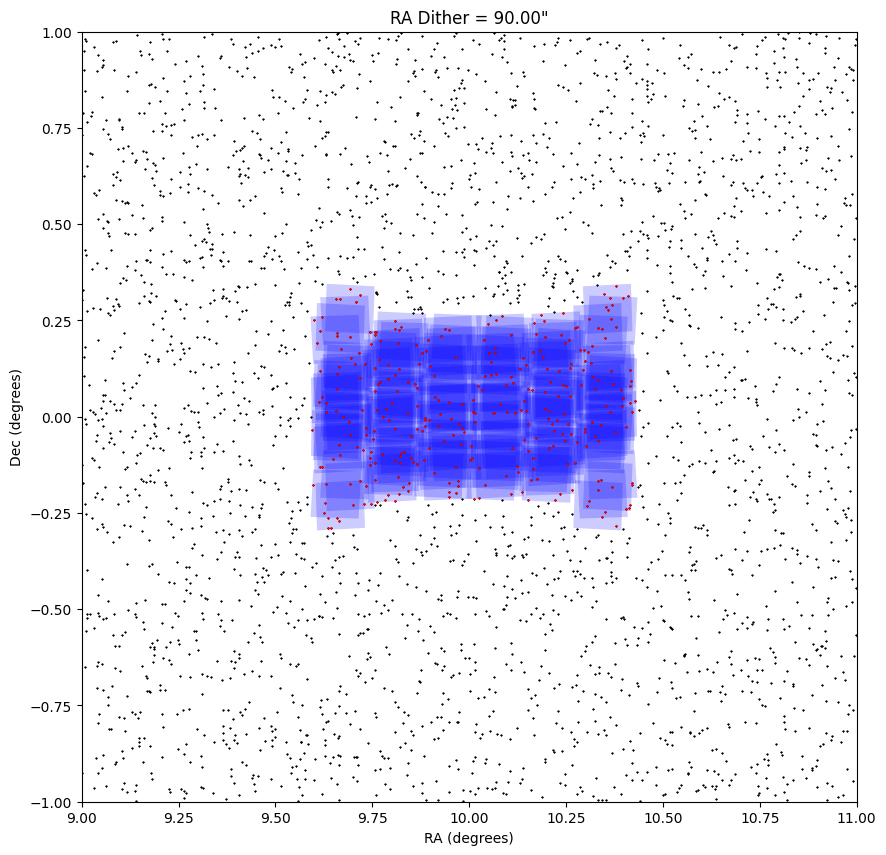

In [26]:
# Create a figure and an axes
fig, ax = plt.subplots(figsize = (10,10))
for footprint in exp:
  corners = footprints[footprint]['vertices']
  polygon = patches.Polygon(corners, closed=True, alpha = 0.2, facecolor = 'blue')
  ax.add_patch(polygon)
plt.plot(RA, DEC, "*", color = "black", markersize = 1)
plt.plot(stars_obs[:,0], stars_obs[:,1], "*", color = "r", markersize = 1)
# Define box edges
xmi, xma = 9.0, 11.0
ymi, yma = -1.0, 1.0

# plt.plot([xmi, xma, xma, xmi, xmi],
#          [ymi, ymi, yma, yma, ymi],
#          'r--', linewidth=2)

plt.xlim(9,11)
plt.ylim(-1,1)
plt.title("RA Dither = {0:.2f}\"".format(90*dithersize))
# Display the plot
plt.xlabel('RA (degrees)')
plt.ylabel('Dec (degrees)')
plt.show()

In [27]:
sigk = 0.5
true_k = np.random.normal(0,sigk,len(exp))
true_k -= np.mean(true_k)
exists_in_exp = np.zeros((Nexp, Nstars), dtype=bool)

for i in exp:
    mask = np.zeros(Nstars, dtype=bool) #initialise all false
        #loop through every detector (theres probably a faster way to do this)
        #do path contains points for each exposure
    path = footprints[i]['path']
    mask |= path.contains_points(stars_obs)      
    exists_in_exp[i-1] = mask

100%|██████████| 144/144 [00:31<00:00,  4.59it/s]


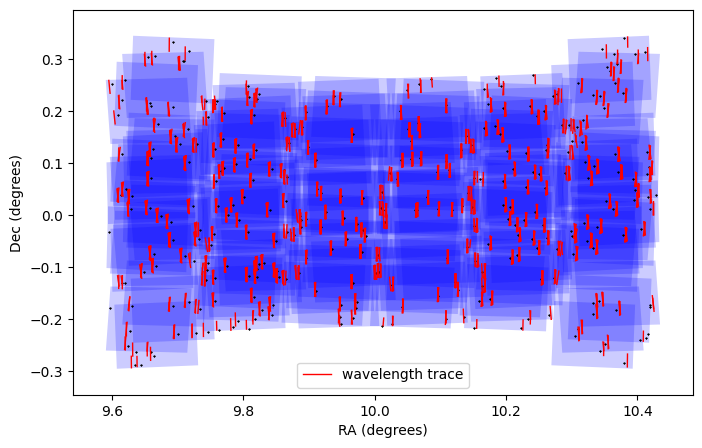

In [28]:
fig, ax = plt.subplots(figsize = (8,5))
for footprint in exp:
    corners = footprints[footprint]['vertices']
    polygon = patches.Polygon(corners, closed=True, alpha = 0.2, facecolor = 'blue')
    ax.add_patch(polygon)
    # Add the footprint label at the centroid of the polygon
    centroid = np.mean(corners, axis=0)
    # ax.text(centroid[0], centroid[1], str(footprint), color='black', fontsize=10, ha='center', va='center')

plt.plot(stars_obs[:,0], stars_obs[:,1], "*", color = "black", markersize = 1)
plt.xlim(xlim)
plt.ylim(ylim)
plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")

# plt.xlim(-0.45, -0.30)
# plt.ylim(-0.08, 0.08)

"""apply grism information to stars"""

wvl_bins = len(master_bins)
stars_wvl = {key: val for key, val in zip(master_bins, [[] for _ in range(wvl_bins)])}

star_colors = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'cyan']
starids = np.arange(len(stars_obs))

for i in tqdm(range(len(exp))):
    star_mask = exists_in_exp[i]
    stars_in_exp = stars_obs[star_mask]
    stars_in_exp_ids = starids[star_mask]
    # stars_in_exp_true_bright = true_brightness[star_mask]
    for star, id in zip(stars_in_exp, stars_in_exp_ids):
        fid = (i + 1)
        scaid = fid - 18 * np.floor((fid) / 18)  # Adjust fiducial ID to be in range 1-18
        if scaid == 0:
            scaid = 18
        rap = f'WFI{int(scaid)-1 + 1:02}_FULL'
        wfi = rsiaf[rap]
        att = footprints[i+1]["attitude"]
        wfi.set_attitude_matrix(att)
        det_star_coord = wfi.sky_to_sci(star[0], star[1])
        # det_pixl = np.floor(det_star_coord)
        coeff = optmod._get_beam_trace(det_star_coord[0], det_star_coord[1], scaid, width=1, order="+1")
        x_binned, y_binned, colors, select_on_detector, bins = bin_cut(coeff)

        #########
        #########
        
        # Convert detector pixel -> telescope frame
        v2, v3 = wfi.sci_to_tel(x_binned, y_binned)
    
        # Get WFI_CEN aperture
        cen = rsiaf['WFI_CEN']
        cen.set_attitude_matrix(att)
    
        # Convert telescope coords -> WFI_CEN frame
        v2_cen, v3_cen = cen.tel_to_idl(v2, v3)
    
        # Distance in arcsec
        dist_arcsec = np.sqrt(v2_cen**2 + v3_cen**2)
    
        # Approx pixel scale (same ~0.11"/pix across detectors)
        # pixscale = 0.5 * (rap.XSciScale + rap.YSciScale)
        # dist_pix = dist_arcsec / pixscale
        dist_deg = dist_arcsec/3600

        #########
        #########

        
        sky_trace_coord = wfi.sci_to_sky(x_binned, y_binned)
        # print(sky_trace_coord[0])
        # break
        temp_dict = {key: val for key, val in [(bin, coord) for bin, coord in zip(bins, np.array([sky_trace_coord[0],sky_trace_coord[1]]).T)]}
        plt.plot(sky_trace_coord[0],sky_trace_coord[1], color="red", lw = 1)
        for b,x,y,r in zip(bins, sky_trace_coord[0], sky_trace_coord[1],dist_deg):
            stars_wvl[b].append((fid, id, x, y, r))


for b in stars_wvl.keys():
    stars_wvl[b] = np.array(stars_wvl[b])
plt.plot(sky_trace_coord[0],sky_trace_coord[1], color="red", lw = 1, label = "wavelength trace")
plt.legend()

plt.xlabel('RA (degrees)')
plt.ylabel('Dec (degrees)')
plt.show()

In [29]:
def logsmoothtp(r):
    return -2.5*np.log10(-0.36 * r **2 + 1)

In [30]:
true_brightness = np.zeros((Nstars, len(master_bins)))
true_errs = np.zeros((Nstars, len(master_bins)))
for i in range(Nstars):
    mags = mag_data[str(mags_obs[i])][:,0]
    errs = mag_data[str(mags_obs[i])][:,1]
    true_brightness[i] = mags
    true_errs[i] = errs
grism_throughput = true_brightness[0] - np.min(true_brightness)
grism_throughput -= np.mean(grism_throughput)
bol_err = np.sqrt(np.sum(true_errs ** 2, axis = 1))

In [42]:
##########################
#BUILD OBSERVATION MATRIX#
##########################

lambda_bins = np.array([k for k in stars_wvl.keys()]) 

m_ijlam = np.zeros((Nexp, Nstars, len(lambda_bins)), dtype=float)  # Initialize m_ijlam with zeros
d_ijlam = np.zeros_like(m_ijlam)


for lam_id, lam in enumerate(stars_wvl.keys()):
    
    
    fids = stars_wvl[lam][:,0]
    starids = stars_wvl[lam][:,1]
    dists = stars_wvl[lam][:,4]
    exists_in_exp = np.zeros((Nexp, Nstars), dtype=bool)

    for i, j in zip(fids, starids):
        exists_in_exp[int(i-1),int(j)] = True
    
    m_ij = [true_brightness[:,lam_id] for _ in range(Nexp)]
    d_ij = np.zeros_like(m_ij)
    m_ij = np.array(m_ij)
    m_ij = np.where(exists_in_exp, m_ij 
                    # - throughput_tiled[:,lam_id][:, None] 
                    - true_k[:, None] 
                    - grism_throughput[lam_id]
                    + np.random.normal(0, true_errs[:,lam_id])[None, :]
                    ,0.0)
    for i, j, d in zip(fids, starids, dists):
        # m_ij[int(i-1),int(j)] -= logsmoothtp(d)
        d_ij[int(i-1),int(j)] = d
        
    m_ijlam[:,:,lam_id] = m_ij 
    d_ijlam[:,:,lam_id] = d_ij
    
# m_ijlam = np.array(m_ijlam)

#######################
#RUN CHI2 MINIMISATION#
#######################

kappa_ilam_j = np.zeros((Nexp, len(lambda_bins)), dtype=float)  # Initialize kappa_ilam with zeros
m_ijlam_cal = m_ijlam

start = time.time()

for i in range(Nexp):
    m_jlam = m_ijlam[i]
    
    m_lamj = m_jlam.T  # Transpose to get shape (Nlam, Nstars)
   

    k_test = np.ones(len(lambda_bins))  # Initialize k_test with zeros
    resJ_lam = minimize(chi2J_lam, k_test, method='L-BFGS-B', args=(m_lamj, true_errs.T, sigk), jac = True)

    out_lam = resJ_lam.x
    kappa_ilam_j[i, :] = out_lam  # Store the fitted kappa values for each exposure and wavelength bin

nonzero_mask = m_ijlam_cal != 0.0
for j in range(len(stars_obs)):
    m_ijlam_cal[:, j, :] += kappa_ilam_j
m_ijlam_cal *= nonzero_mask

k_i_j = np.zeros((Nexp, len(lambda_bins)), dtype=float)

for lam in range(len(lambda_bins)):
    m_ij = m_ijlam_cal[:,:,lam]
    k_test = np.zeros(Nexp)  # Initialize k_test with zeros
    resJ_vec = minimize(chi2J_vec, k_test, method='L-BFGS-B', args=(m_ij, true_errs[:,lam_id], sigk), jac = True)
    out_k_j = resJ_vec.x
    k_i_j[:,lam] = out_k_j
print(time.time() - start)





3.167933702468872


In [32]:
m_ij.shape

(144, 315)

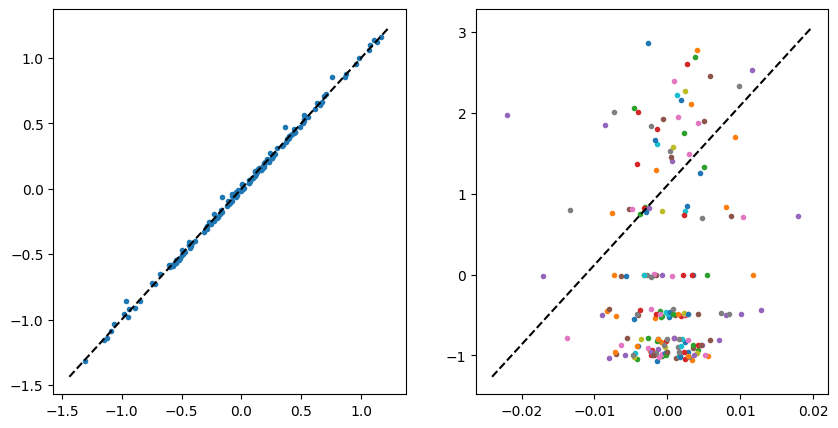

In [43]:
plt.figure(figsize = (10,5))
plt.subplot(1, 2, 1)
plt.plot(np.mean(k_i_j, axis = 1), true_k+throughput_k_tiled, '.')
plt.plot(np.linspace(np.min(out_k_j)*1.1, np.max(out_k_j)*1.1,100), np.linspace(np.min(out_k_j)*1.1, np.max(out_k_j)*1.1,100), '--', color = "black")
plt.subplot(1, 2, 2)
for tid in range(18):
    out_lam = kappa_ilam_j[tid, :]  # Use the first exposure's fitted kappa values for plotting
    plt.plot(out_lam, throughput_data[tid]-np.mean(throughput_data[tid]), '.')
xmin, xmax = plt.xlim()  # returns (xmin, xmax)
ymin, ymax = plt.ylim()  # returns (ymin, ymax)
plt.plot(np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100), '--', color = "black")
plt.show()

np.float64(0.017740277542053387)

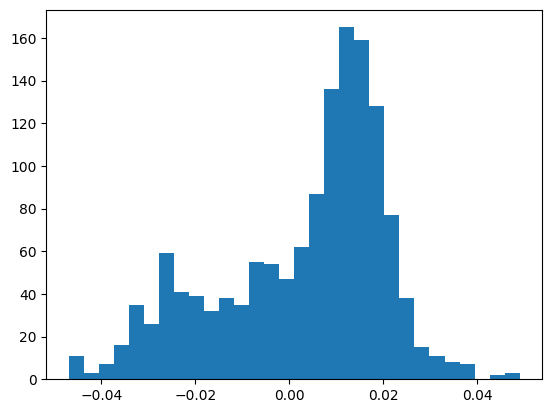

In [44]:
res = k_i_j - (true_k+throughput_k_tiled)[:,None]
plt.hist(res[np.abs(res) < 0.05], bins = 30);

np.std(res[np.abs(res) < 0.05])

100%|██████████| 18/18 [00:00<00:00, 154.48it/s]


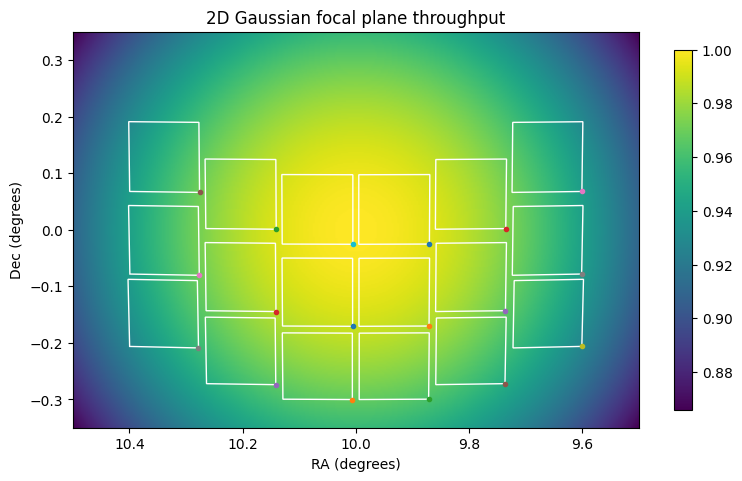

In [36]:
# Mock heatmap grid
x = np.linspace(9.5, 10.5, 300)
y = np.linspace(-0.35, 0.35, 300)
X, Y = np.meshgrid(x, y)

def smooth_thru(x, y, params):
    x0,y0,a,b = params
    Z = (6*(x - x0)/a)**2 + (6*(y - y0)/b)**2
    Z *= -1
    Z = Z + 1 - np.max(Z)
    return Z
Z = smooth_thru(X,Y, [10,0,10,10])

fig, ax = plt.subplots(figsize=(8, 5.5))

# Heatmap
cmap = plt.get_cmap('viridis')
im = ax.imshow(Z, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', cmap=cmap)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink = 0.7)
cbar.set_label("")
rsiaf = pysiaf.Siaf('Roman')
cen_ra = 10.0
cen_dec = 0.0
cen_pa = 0.0
pa_v3 = 60

pointing_coords = [[cen_ra, cen_dec, cen_pa]]
footprints = {}
for i in range(len(pointing_coords)):
    cen_ra = pointing_coords[i][0]
    cen_dec = pointing_coords[i][1]
    cen_pa = pointing_coords[i][2]
    pa_v3 = 60
    wfi_cen = rsiaf['WFI_CEN'] 
    att = attitude(wfi_cen.V2Ref, wfi_cen.V3Ref, cen_ra, cen_dec, pa_v3+cen_pa)
    for detector in range(1,19):
        rap = f'WFI{detector-1 + 1:02}_FULL'
        # print(rap)
        wfi = rsiaf[rap]
        wfi.set_attitude_matrix(att)
        corners_x = np.array([1,4088,4088,1,1])
        corners_y = np.array([1,1,4088,4088,1])
        corners_ra,corners_dec = wfi.sci_to_sky(corners_x, corners_y)
        corners = np.zeros((5,2))
        corners[:,0] = corners_ra
        corners[:,1] = corners_dec
        footprints[detector+i*18] = my_dict = {'vertices': corners,
                                               'path': 0,
                                               'attitude': att
                                                }

for footprint in range(1,19):
    data = footprints[footprint]
    corners = data['vertices']
    polygon = patches.Polygon(corners, closed=True,  
                            facecolor = 'None', edgecolor = "white")
    
    ax.add_patch(polygon)
    if footprint == 18:
        break

wfi_cen = rsiaf['WFI_CEN'] 
att = attitude(wfi_cen.V2Ref, wfi_cen.V3Ref, cen_ra, cen_dec, pa_v3+cen_pa)
for scaid in tqdm(range(0,18)):
    rap = f'WFI{int(scaid) + 1:02}_FULL'
    wfi = rsiaf[rap]
    wfi.set_attitude_matrix(att)
    cx, cy = wfi.sci_to_sky(4088,0)
    plt.plot(cx, cy, ".")

# centres_list = np.array(centres_list)
# smooth_k = smooth_thru(centres_list[:,0], centres_list[:,1])
# log_smooth_k = np.log(smooth_k)

ax.set_xlabel("RA (degrees)")
ax.set_ylabel("Dec (degrees)")
ax.set_title("2D Gaussian focal plane throughput")
ax.invert_xaxis()
plt.tight_layout()
plt.show()


In [37]:
lklk = np.arange(0,12)
print(lklk)
print(lklk[:-2], lklk[-2:])

[ 0  1  2  3  4  5  6  7  8  9 10 11]
[0 1 2 3 4 5 6 7 8 9] [10 11]


In [38]:
# ##########################
# #BUILD OBSERVATION MATRIX#
# ##########################

# lambda_bins = np.array([k for k in stars_wvl.keys()]) 

# m_ijlam = np.zeros((Nexp, Nstars, len(lambda_bins)), dtype=float)  # Initialize m_ijlam with zeros
# d_ijlam = np.zeros_like(m_ijlam)


# for lam_id, lam in enumerate(stars_wvl.keys()):
    
    
#     fids = stars_wvl[lam][:,0]
#     starids = stars_wvl[lam][:,1]
#     dists = stars_wvl[lam][:,4]
#     exists_in_exp = np.zeros((Nexp, Nstars), dtype=bool)

#     for i, j in zip(fids, starids):
#         exists_in_exp[int(i-1),int(j)] = True
    
#     m_ij = [true_brightness[:,lam_id] for _ in range(Nexp)]
#     d_ij = np.zeros_like(m_ij)
#     m_ij = np.array(m_ij)
#     m_ij = np.where(exists_in_exp, m_ij 
#                     - throughput_tiled[:,lam_id][:, None] 
#                     - true_k[:, None] 
#                     - grism_throughput[lam_id]
#                     + np.random.normal(0, true_errs[:,0])[None, :]
#                     ,0.0)
#     for i, j, d in zip(fids, starids, dists):
#         m_ij[int(i-1),int(j)] -= logsmoothtp(d)
#         m_ij[int(i-1),int(j)] = d
        
#     m_ijlam[:,:,lam_id] = m_ij 
#     d_ijlam[:,:,lam_id] = d_ij
    
# # m_ijlam = np.array(m_ijlam)

# #######################
# #RUN CHI2 MINIMISATION#
# #######################

# kappa_ilam_j = np.zeros((Nexp, len(lambda_bins)), dtype=float)  # Initialize kappa_ilam with zeros
# m_ijlam_cal = m_ijlam
# ab = []
# start = time.time()

# for i in range(Nexp):
#     m_jlam = m_ijlam[i]
#     d_jlam = d_ijlam[i]
#     m_lamj = m_jlam.T  # Transpose to get shape (Nlam, Nstars)
#     d_lamj = d_jlam.T

#     k_test = np.ones(len(lambda_bins))  # Initialize k_test with zeros
#     resJ_lam = minimize(chi2J_lam, k_test, method='L-BFGS-B', args=(m_lamj, true_errs.T, sigk), jac = False)

#     out_lam = resJ_lam.x
#     kappa_ilam_j[i, :] = out_lam  # Store the fitted kappa values for each exposure and wavelength bin
# print(time.time() - start)

# nonzero_mask = m_ijlam_cal != 0.0
# for j in range(len(stars_obs)):
#     m_ijlam_cal[:, j, :] += kappa_ilam_j

# m_ijlam_cal *= nonzero_mask

# num_lam_meas = np.count_nonzero(m_ijlam_cal, axis=2)
# full_lam_meas = (num_lam_meas == 10)
# denoms = full_lam_meas * num_lam_meas
# denoms = np.where(denoms == 0, np.inf, denoms)
# m_ij = np.sum(m_ijlam_cal, axis=2)/denoms  # Sum over wavelength bins

# k_test = np.zeros(Nexp)  # Initialize k_test with zeros

# start = time.time()
# # cali = run_calibration(stars_wvl, exp, stars_obs, sig_ij, sigk, true_brightness, true_k, throughput_data)
# resJ_vec = minimize(chi2J_vec, k_test, method='L-BFGS-B', args=(m_ij, bol_err, sigk), jac = True)
# print(time.time() - start)

# out_k_j = resJ_vec.x
